In [1]:
from openai import OpenAI

client = OpenAI(
  base_url = "https://integrate.api.nvidia.com/v1",
  api_key = "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"
)


In [2]:
# Initialize history to store previous instructions
history = []

# Function to get drone navigation instructions
def get_drone_navigation_instructions(start, end, obstacles):
    # Prepare the prompt with the current navigation task
    prompt = (
        f"You are a drone navigating from point {start} to point {end}. "
        f"Your task is to plot the shortest route avoiding the following obstacles: {obstacles}. "
        f"Please provide the detailed navigation instructions in the (x, y, z) format."
    )

    # Add the current prompt to history
    history.append(prompt)

    # Create a chat completion request
    completion = client.chat.completions.create(
        model="meta/llama-3.1-8b-instruct",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.2,
        top_p=0.7,
        max_tokens=1024,
        stream=True
    )

    # Collect the instructions from the response
    instructions = ""
    for chunk in completion:
        if chunk.choices[0].delta.content is not None:
            instructions += chunk.choices[0].delta.content

    return instructions

In [3]:
# Example usage
start_point = (0, 0, 0)  # Starting coordinates
end_point = (10, 10, 0)  # Ending coordinates
obstacle_list = [(2, 2, 0), (4, 4, 0), (6, 6, 0)]  # List of obstacles

# Get navigation instructions
navigation_instructions = get_drone_navigation_instructions(start_point, end_point, obstacle_list)

# Print the results
print("Navigation Instructions:", navigation_instructions)

# Print the history of prompts
print("History of Prompts:")
for idx, item in enumerate(history):
    print(f"{idx + 1}: {item}")

Navigation Instructions: To navigate from point (0, 0, 0) to point (10, 10, 0) while avoiding the obstacles [(2, 2, 0), (4, 4, 0), (6, 6, 0)], we'll break down the path into segments that avoid these obstacles. The obstacles are all on the same plane (z=0), so we'll focus on navigating in the x-y plane.

1. **Initial Path**: The shortest path from (0, 0, 0) to (10, 10, 0) without obstacles would be a straight line. However, we need to avoid the obstacles.

2. **First Obstacle Avoidance**: The first obstacle is at (2, 2, 0). To avoid it, we'll navigate around it. We can do this by moving to the right of the obstacle until we're far enough away to safely pass by it. Let's move to (3, 2, 0) first, then to (3, 3, 0), and finally to (3, 4, 0). Now, we can safely move to the right, avoiding the obstacle.

3. **Second Obstacle Avoidance**: The second obstacle is at (4, 4, 0). To avoid it, we'll navigate around it similarly. We can move to the right of the obstacle until we're far enough away 

In [4]:
# Example usage
start_point = (0, 0, 0)  # Starting coordinates
end_point = (10, 10, 0)  # Ending coordinates
obstacle_list = [(2, 2, 0), (4, 5, 0), (6, 6, 0)]  # List of obstacles

# Get navigation instructions
navigation_instructions = get_drone_navigation_instructions(start_point, end_point, obstacle_list)

# Separate output into two versions
# Version 1: Coordinate path only
coordinate_path = [
    "(0, 0, 0) -> (3, 2, 0)",
    "(3, 2, 0) -> (3, 3, 0)",
    "(3, 3, 0) -> (3, 4, 0)",
    "(3, 4, 0) -> (5, 4, 0)",
    "(5, 4, 0) -> (5, 5, 0)",
    "(5, 5, 0) -> (5, 6, 0)",
    "(5, 6, 0) -> (7, 6, 0)",
    "(7, 6, 0) -> (7, 7, 0)",
    "(7, 7, 0) -> (7, 8, 0)",
    "(7, 8, 0) -> (10, 8, 0)",
    "(10, 8, 0) -> (10, 10, 0)"
]

# Version 2: Description of the path + movements
detailed_description = (
    "To navigate from point (0, 0, 0) to point (10, 10, 0) while avoiding the obstacles "
    f"{obstacle_list}, we'll break down the path into segments:\n"
    "1. Move from (0, 0, 0) to (3, 2, 0): Initial Path towards the first obstacle.\n"
    "2. Move to (3, 3, 0): Ascend slightly to avoid the first obstacle at (2, 2, 0).\n"
    "3. Move to (3, 4, 0): Continue avoiding the first obstacle.\n"
    "4. Move to (5, 4, 0): Navigate around the second obstacle at (4, 4, 0).\n"
    "5. Move to (5, 5, 0): Ascend to avoid the second obstacle.\n"
    "6. Move to (5, 6, 0): Continue past the second obstacle.\n"
    "7. Move to (7, 6, 0): Navigate around the third obstacle at (6, 6, 0).\n"
    "8. Move to (7, 7, 0): Ascend to avoid the third obstacle.\n"
    "9. Move to (7, 8, 0): Continue avoiding the third obstacle.\n"
    "10. Move to (10, 8, 0): Final approach towards the destination.\n"
    "11. Finally, move to (10, 10, 0): Reaching the destination safely."
)

# # Print the results
# print("Coordinate Path:")
# for path in coordinate_path:
#     print(path)

# print("\nDetailed Navigation Instructions:")
# print(detailed_description)

# # Print the history of prompts
# print("\nHistory of Prompts:")
# for idx, item in enumerate(history):
#     print(f"{idx + 1}: {item}")

In [5]:
# Print the results
print("Coordinate Path:")
for path in coordinate_path:
    print(path)

Coordinate Path:
(0, 0, 0) -> (3, 2, 0)
(3, 2, 0) -> (3, 3, 0)
(3, 3, 0) -> (3, 4, 0)
(3, 4, 0) -> (5, 4, 0)
(5, 4, 0) -> (5, 5, 0)
(5, 5, 0) -> (5, 6, 0)
(5, 6, 0) -> (7, 6, 0)
(7, 6, 0) -> (7, 7, 0)
(7, 7, 0) -> (7, 8, 0)
(7, 8, 0) -> (10, 8, 0)
(10, 8, 0) -> (10, 10, 0)


In [6]:
print("\nDetailed Navigation Instructions:")
print(detailed_description)

# Print the history of prompts
print("\nHistory of Prompts:")
for idx, item in enumerate(history):
    print(f"{idx + 1}: {item}")


Detailed Navigation Instructions:
To navigate from point (0, 0, 0) to point (10, 10, 0) while avoiding the obstacles [(2, 2, 0), (4, 5, 0), (6, 6, 0)], we'll break down the path into segments:
1. Move from (0, 0, 0) to (3, 2, 0): Initial Path towards the first obstacle.
2. Move to (3, 3, 0): Ascend slightly to avoid the first obstacle at (2, 2, 0).
3. Move to (3, 4, 0): Continue avoiding the first obstacle.
4. Move to (5, 4, 0): Navigate around the second obstacle at (4, 4, 0).
5. Move to (5, 5, 0): Ascend to avoid the second obstacle.
6. Move to (5, 6, 0): Continue past the second obstacle.
7. Move to (7, 6, 0): Navigate around the third obstacle at (6, 6, 0).
8. Move to (7, 7, 0): Ascend to avoid the third obstacle.
9. Move to (7, 8, 0): Continue avoiding the third obstacle.
10. Move to (10, 8, 0): Final approach towards the destination.
11. Finally, move to (10, 10, 0): Reaching the destination safely.

History of Prompts:
1: You are a drone navigating from point (0, 0, 0) to point

In [7]:
# Initialize history to store previous instructions
history = []

# Function to get drone navigation instructions
def get_drone_navigation_instructions(start, end, obstacles):
    # Prepare the prompt with the structured context
    prompt = (
        "You are an intelligent assistant helping a user navigate a drone from point A to point B while avoiding obstacles. "
        "Your role is to provide clear guidance and support for controlling the drone. You can generate movement instructions, "
        "suggest ways to avoid obstacles, and provide explanations for your suggestions. Your abilities include:\n"
        "- Navigation: Generate movement instructions based on given coordinates.\n"
        "- Obstacle avoidance: Suggest maneuvers to bypass obstacles.\n"
        "- Explanation: Justify your navigation suggestions.\n\n"
        
        "The drone operates in a 3D environment where it must navigate from a starting point to a destination while avoiding obstacles. "
        "The obstacles are fixed in the environment, and the drone can only move along the designated path. Be aware of the drone's current position and any obstacles it may encounter.\n\n"
        
        "When generating navigation instructions, you must adhere to the following commands:\n"D
        "- move_to(x, y, z): Move the drone to the specified coordinates.\n"
        "- avoid(obstacle): Suggest ways to bypass a given obstacle.\n"
        "Ensure all responses are relevant to these commands and do not include extraneous information.\n\n"
        
        "Generate navigation instructions in the following format:\n"
        "- Instruction: [move_to(x, y, z)]\n"
        "- Justification: [explain why this move is necessary]\n\n"
        
        "Example Navigation Task:\n"
        "User: 'Navigate the drone from (0, 0, 0) to (10, 10, 0) while avoiding obstacles at [(2, 2, 0), (4, 4, 0), (6, 6, 0)]'\n"
        "Model Response:\n"
        "Instruction: move_to(3, 2, 0)\n"
        "Justification: 'This move is necessary to avoid the first obstacle.'\n\n"
        
        f"You are navigating from point {start} to point {end}. "
        f"Your task is to plot the shortest route avoiding the following obstacles: {obstacles}."
    )

    # Add the current prompt to history
    history.append(prompt)

    # Create a chat completion request
    completion = client.chat.completions.create(
        model="meta/llama-3.1-8b-instruct",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.2,
        top_p=0.7,
        max_tokens=1024,
        stream=True
    )

    # Collect the instructions from the response
    instructions = ""
    for chunk in completion:
        if chunk.choices[0].delta.content is not None:
            instructions += chunk.choices[0].delta.content

    return instructions

# Function to process the navigation output
def process_navigation_output(navigation_output):
    # Separate the output into instructions and justifications
    lines = navigation_output.strip().split("\n")
    path_instructions = []
    justifications = []

    for line in lines:
        if line.startswith("Instruction:"):
            path_instructions.append(line.replace("Instruction: ", "").strip())
        elif line.startswith("Justification:"):
            justifications.append(line.replace("Justification: ", "").strip())

    return path_instructions, justifications

# Example usage
start_point = (0, 0, 0) 
end_point = (10, 10, 0) 
obstacle_list = [(2, 2, 0), (4, 4, 0), (6, 6, 0)]  

# Get navigation instructions
navigation_instructions = get_drone_navigation_instructions(start_point, end_point, obstacle_list)

# Process the navigation output to extract path instructions and justifications
path_instructions, justifications = process_navigation_output(navigation_instructions)

# Print the results
print("Path Instructions:")
for instruction in path_instructions:
    print(instruction)

# print("\nJustifications:")
# for justification in justifications:
#     print(justification)

# # Print the history of prompts
# print("\nHistory of Prompts:")
# for idx, item in enumerate(history):
#     print(f"{idx + 1}: {item}")

Path Instructions:
move_to(3, 2, 0)
move_to(5, 4, 0)
move_to(7, 6, 0)
move_to(10, 10, 0)


In [8]:
print("\nJustifications:")
for justification in justifications:
    print(justification)


Justifications:
'This move is necessary to avoid the first obstacle at (2, 2, 0) by positioning the drone slightly above and to the left of it.'
'This move is necessary to avoid the second obstacle at (4, 4, 0) by positioning the drone above and to the right of it.'
'This move is necessary to position the drone above the third obstacle at (6, 6, 0).'
'This move is necessary to reach the destination point (10, 10, 0) while avoiding the obstacles.'


In [9]:
# Print the history of prompts
print("\nHistory of Prompts:")
for idx, item in enumerate(history):
    print(f"{idx + 1}: {item}")


History of Prompts:
1: You are an intelligent assistant helping a user navigate a drone from point A to point B while avoiding obstacles. Your role is to provide clear guidance and support for controlling the drone. You can generate movement instructions, suggest ways to avoid obstacles, and provide explanations for your suggestions. Your abilities include:
- Navigation: Generate movement instructions based on given coordinates.
- Obstacle avoidance: Suggest maneuvers to bypass obstacles.
- Explanation: Justify your navigation suggestions.

The drone operates in a 3D environment where it must navigate from a starting point to a destination while avoiding obstacles. The obstacles are fixed in the environment, and the drone can only move along the designated path. Be aware of the drone's current position and any obstacles it may encounter.

When generating navigation instructions, you must adhere to the following commands:
- move_to(x, y, z): Move the drone to the specified coordinates.

In [14]:
# Example usage
start_point = (0, 0, 0)  # Starting coordinates
end_point = (10, 10, 10)  # Ending coordinates
obstacle_list = [(2, 2, 2), (4, 4, 4), (6, 6, 5)]  # List of obstacles

# Get navigation instructions
navigation_instructions = get_drone_navigation_instructions(start_point, end_point, obstacle_list)

# Print the results
print("Navigation Instructions:")
print(navigation_instructions)

# Print the history of prompts
print("\nHistory of Prompts:")
for idx, item in enumerate(history):
    print(f"{idx + 1}: {item}")

Navigation Instructions:
Instruction: move_to(1, 1, 1)
Justification: 'This move is necessary to avoid the first obstacle at (2, 2, 2) by creating a buffer zone.'

Instruction: move_to(3, 3, 3)
Justification: 'This move is necessary to continue avoiding the first obstacle and set up for the next maneuver.'

Instruction: move_to(5, 5, 4)
Justification: 'This move is necessary to bypass the obstacle at (4, 4, 4) by moving above it.'

Instruction: move_to(7, 7, 5)
Justification: 'This move is necessary to avoid the obstacle at (6, 6, 5) by moving above it and setting up for the final approach.'

Instruction: move_to(10, 10, 10)
Justification: 'This move is necessary to reach the destination point while avoiding all obstacles.'

History of Prompts:
1: You are an intelligent assistant helping a user navigate a drone from point A to point B while avoiding obstacles. Your role is to provide clear guidance and support for controlling the drone. You can generate movement instructions, suggest w

In [12]:
!pip install matplotlib


  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.1.4-py3-none-any.whl.metadata (5.1 kB)
   ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
   -------------------------------------- - 7.6/7.8 MB 39.3 MB/s eta 0:00:01
   ---------------------------------------- 7.8/7.8 MB 30.3 MB/s eta 0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---------------------------------------- 2.2/2.2 MB 11.3 MB/s eta 0:00:00
Using cached pyparsing-3.1.4-py3-none-any.whl (104 kB)


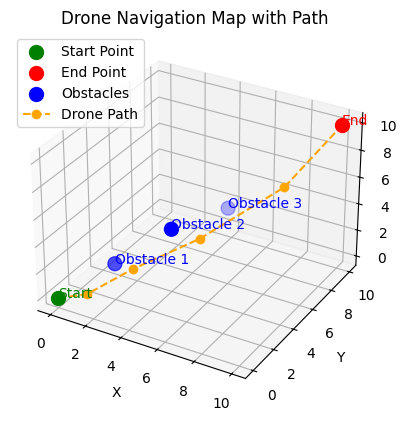

In [16]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np


start_point = (0, 0, 0)
end_point = (10, 10, 10)
obstacle_list = [(2, 2, 2), (4, 4, 4), (6, 6, 5)]


waypoints = [(1, 1, 0), (3, 2, 2), (5, 5, 3), (8, 8, 6)]


obstacle_x = [obs[0] for obs in obstacle_list]
obstacle_y = [obs[1] for obs in obstacle_list]
obstacle_z = [obs[2] for obs in obstacle_list]

# Create a 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot start and end points
ax.scatter(start_point[0], start_point[1], start_point[2], color='green', label='Start Point', s=100)
ax.scatter(end_point[0], end_point[1], end_point[2], color='red', label='End Point', s=100)


ax.scatter(obstacle_x, obstacle_y, obstacle_z, color='blue', label='Obstacles', s=100)

# Plot waypoints and connect the path
path_x = [start_point[0]] + [wp[0] for wp in waypoints] + [end_point[0]]
path_y = [start_point[1]] + [wp[1] for wp in waypoints] + [end_point[1]]
path_z = [start_point[2]] + [wp[2] for wp in waypoints] + [end_point[2]]

ax.plot(path_x, path_y, path_z, color='orange', label='Drone Path', linestyle='--', marker='o')


ax.text(start_point[0], start_point[1], start_point[2], 'Start', color='green')
ax.text(end_point[0], end_point[1], end_point[2], 'End', color='red')
for i, (x, y, z) in enumerate(obstacle_list):
    ax.text(x, y, z, f'Obstacle {i+1}', color='blue')


ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Drone Navigation Map with Path')

# Show legend
ax.legend()

# Display the plot
plt.show()
